In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import chineseize_matplotlib  # 注册 SimHei，避免标题/坐标轴中文乱码

LOG_PATH = os.path.join(os.path.dirname(os.path.abspath("log_watcher.ipynb")),
                        "logs", "train_log.csv")
print("读取：", LOG_PATH)

读取： /home/huanghao/KK/Orbit_War/scripts/v4_NN/logs/train_log.csv


已训练迭代：150，最新 iter=150


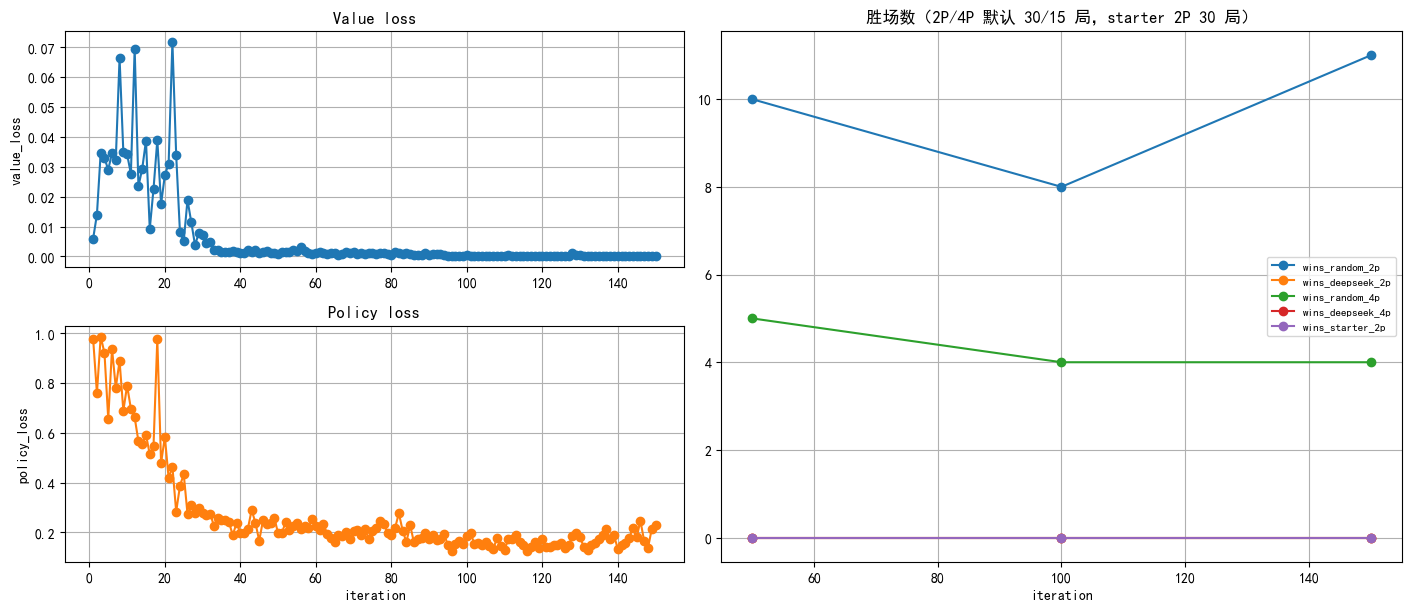

In [7]:
if not os.path.exists(LOG_PATH):
    raise FileNotFoundError(f"未找到 {LOG_PATH}，请先跑训练（每 iter 写 loss，每 50 iter 写 eval）")

df = pd.read_csv(LOG_PATH)
print(f"已训练迭代：{len(df)}，最新 iter={df['iteration'].iloc[-1]}")

win_cols = [c for c in df.columns if c.startswith("wins_")]
eval_df = df.dropna(subset=win_cols[:1]).copy()

fig = plt.figure(figsize=(14, 6), layout="constrained")
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.1])
ax_v = fig.add_subplot(gs[0, 0])
ax_p = fig.add_subplot(gs[1, 0])
ax_w = fig.add_subplot(gs[:, 1])

x = df["iteration"]
ax_v.plot(x, df["value_loss"], color="C0", marker="o", label="value_loss")
ax_v.set_title("Value loss")
ax_v.set_ylabel("value_loss")
ax_v.grid(True)

ax_p.plot(x, df["policy_loss"], color="C1", marker="o", label="policy_loss")
ax_p.set_title("Policy loss")
ax_p.set_xlabel("iteration")
ax_p.set_ylabel("policy_loss")
ax_p.grid(True)

if not eval_df.empty:
    for col in win_cols:
        ax_w.plot(eval_df["iteration"], eval_df[col], marker="o", label=col)
    ax_w.set_title("胜场数（2P/4P 默认 30/15 局，starter 2P 30 局）")
    ax_w.set_xlabel("iteration")
    ax_w.legend(fontsize=8)
    ax_w.grid(True)
else:
    ax_w.set_title("暂无评估数据（等到 iter 50）")

plt.show()

In [8]:
# 最近 5 条数字摘要
print(f"最近 value_loss ：{df['value_loss'].dropna().tail(5).values}")
print(f"最近 policy_loss：{df['policy_loss'].dropna().tail(5).values}")

if win_cols:
    eval_tail = df[df[win_cols[0]].notna()][["iteration"] + win_cols].tail(5)
    if not eval_tail.empty:
        print("\n最近评估结果：")
        print(eval_tail.to_string(index=False))

最近 value_loss ：[1.26310464e-04 1.11709778e-04 1.88780577e-05 6.75361371e-05
 1.57873932e-04]
最近 policy_loss：[0.24666736 0.16508061 0.13663396 0.21310607 0.22827742]

最近评估结果：
 iteration  wins_random_2p  wins_deepseek_2p  wins_random_4p  wins_deepseek_4p  wins_starter_2p
        50            10.0               0.0             5.0               0.0              0.0
       100             8.0               0.0             4.0               0.0              0.0
       150            11.0               0.0             4.0               0.0              0.0
